Epoch 1/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.7794 - loss: 0.6197 - val_accuracy: 0.8407 - val_loss: 0.4384
Epoch 2/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.8440 - loss: 0.4344 - val_accuracy: 0.8618 - val_loss: 0.3697
Epoch 3/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.8562 - loss: 0.3973 - val_accuracy: 0.8687 - val_loss: 0.3573
Epoch 4/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - accuracy: 0.8652 - loss: 0.3712 - val_accuracy: 0.8765 - val_loss: 0.3427
Epoch 5/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.8701 - loss: 0.3554 - val_accuracy: 0.8710 - val_loss: 0.3422
Epoch 6/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.8743 - loss: 0.3433 - val_accuracy: 0.8790 - val_loss: 0.3387
Epoch 7/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8799 - loss: 0.3290 - val_accuracy: 0.8857 - val_loss: 0.3331
Epoch 8/15
844/844 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8821 - loss: 0.3211 - val_accuracy: 0

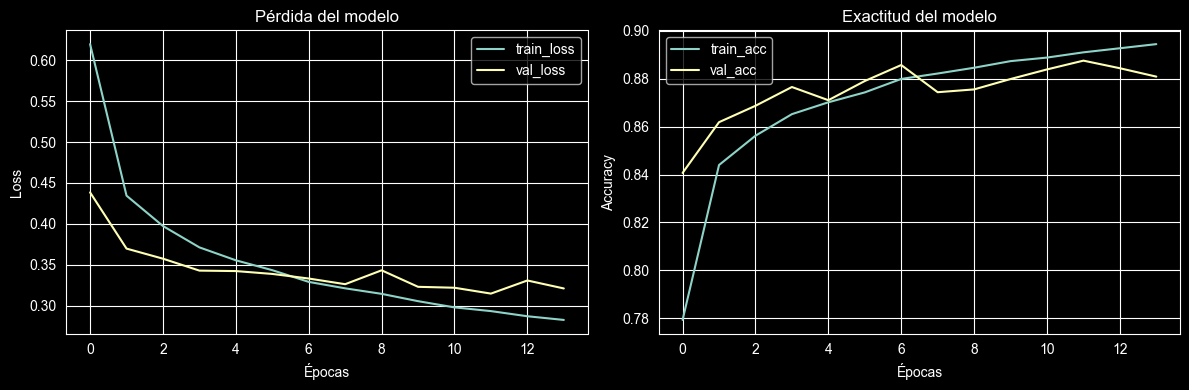

In [3]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import sys
import os

sys.path.append(os.path.abspath("../src"))
from datos_processing import load_and_prepare_all

data = load_and_prepare_all()

x_train = data["x_train_mlp"]
y_train = data["y_train"]
x_test = data["x_test_mlp"]
y_test = data["y_test"]

num_layers = int(input("Ingrese el número de capas ocultas: "))
neuronas_por_capa = [
    int(input(f"Ingrese el número de neuronas para la capa {i+1}: "))
    for i in range(num_layers)
]

model = keras.Sequential()
model.add(layers.Dense(neuronas_por_capa[0], activation='relu', input_shape=(784,)))

for n in neuronas_por_capa[1:]:
    model.add(layers.Dense(n, activation='relu'))

model = keras.Sequential([
    keras.Input(shape=(784,)),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

history = model.fit(
    x_train, y_train,
    epochs=10,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop],
    verbose=1
)
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title("Pérdida del modelo")
plt.xlabel("Épocas")
plt.ylabel("Loss")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.title("Exactitud del modelo")
plt.xlabel("Épocas")
plt.ylabel("Accuracy")
plt.legend()

plt.tight_layout()
plt.show()